In [1]:
import numpy as np
import pandas as pd

files=[
        "../data/raw/Wednesday-workingHours.pcap_ISCX.csv",
        "../data/raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
        "../data/raw/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
        "../data/raw/Tuesday-WorkingHours.pcap_ISCX.csv",
        "../data/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
        "../data/raw/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
        "../data/raw/Friday-WorkingHours-Morning.pcap_ISCX.csv"
    ]

dfs=[]

for file in files:
    temp=pd.read_csv(file)
    temp.columns = temp.columns.str.strip()
    dfs.append(temp)

df=pd.concat(dfs,axis=0,ignore_index=True)

##### Preprocessing

In [2]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

missing_percent = (df.isnull().sum() / len(df)) * 100

df.fillna(df.median(numeric_only=True), inplace=True) #handle missing values

df.drop_duplicates(inplace=True) #remove duplicates

constant_col=df.columns[df.nunique()==1]  #remove constant columns
df.drop(columns=constant_col,inplace=True)

df['Binary_Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1) #binary labeling

df.shape

(2019730, 72)

In [3]:
selected_features = [
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Duration',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'Destination Port',
    'Average Packet Size',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Min Packet Length',
    'Max Packet Length',
    'Fwd Packets/s',
    'Bwd Packets/s'
]

df = df[selected_features + ['Binary_Label']]

df.info()

<class 'pandas.DataFrame'>
Index: 2019730 entries, 0 to 2300824
Data columns (total 20 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Total Fwd Packets            int64  
 1   Total Backward Packets       int64  
 2   Total Length of Fwd Packets  int64  
 3   Total Length of Bwd Packets  int64  
 4   Flow Duration                int64  
 5   Flow Bytes/s                 float64
 6   Flow Packets/s               float64
 7   Packet Length Mean           float64
 8   Packet Length Std            float64
 9   SYN Flag Count               int64  
 10  ACK Flag Count               int64  
 11  Destination Port             int64  
 12  Average Packet Size          float64
 13  Fwd Packet Length Mean       float64
 14  Bwd Packet Length Mean       float64
 15  Min Packet Length            int64  
 16  Max Packet Length            int64  
 17  Fwd Packets/s                float64
 18  Bwd Packets/s                float64
 19  Binary_Label    

In [4]:
df.sample(5)

,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Duration,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,SYN Flag Count,ACK Flag Count,Destination Port,Average Packet Size,Fwd Packet Length Mean,Bwd Packet Length Mean,Min Packet Length,Max Packet Length,Fwd Packets/s,Bwd Packets/s,Binary_Label
1999531,1,1,0,0,58,0.00000,34482.758620,0.000000,0.000000,0,1,49273,0.000000,0.000000,0.000000,0,0,17241.379310,17241.379310,0
996068,2,0,0,0,11074,0.00000,180.603215,0.000000,0.000000,0,1,51760,0.000000,0.000000,0.000000,0,0,180.603215,0.000000,0
936903,13,9,17856,42,22683,789049.06760,969.889344,778.173913,1097.636620,0,0,51036,813.545455,1373.538462,4.666667,0,2920,573.116431,396.772914,0
1827000,1,1,0,0,23204,0.00000,86.192036,0.000000,0.000000,0,1,80,0.000000,0.000000,0.000000,0,0,43.096018,43.096018,0
351355,10,5,739,1519,118564,19044.56665,126.513950,141.125000,353.265505,0,0,443,150.533333,73.900000,303.800000,0,1381,84.342634,42.171317,0


##### EDA

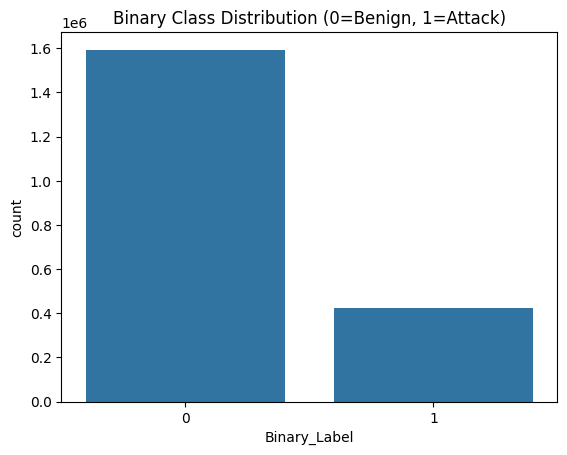

Binary_Label
0    78.914112
1    21.085888
Name: proportion, dtype: float64


In [5]:
X = df.drop(['Binary_Label'], axis=1)  #input output split
y = df["Binary_Label"]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(x=y)
plt.title("Binary Class Distribution (0=Benign, 1=Attack)")
plt.show()

print(y.value_counts(normalize=True)*100)

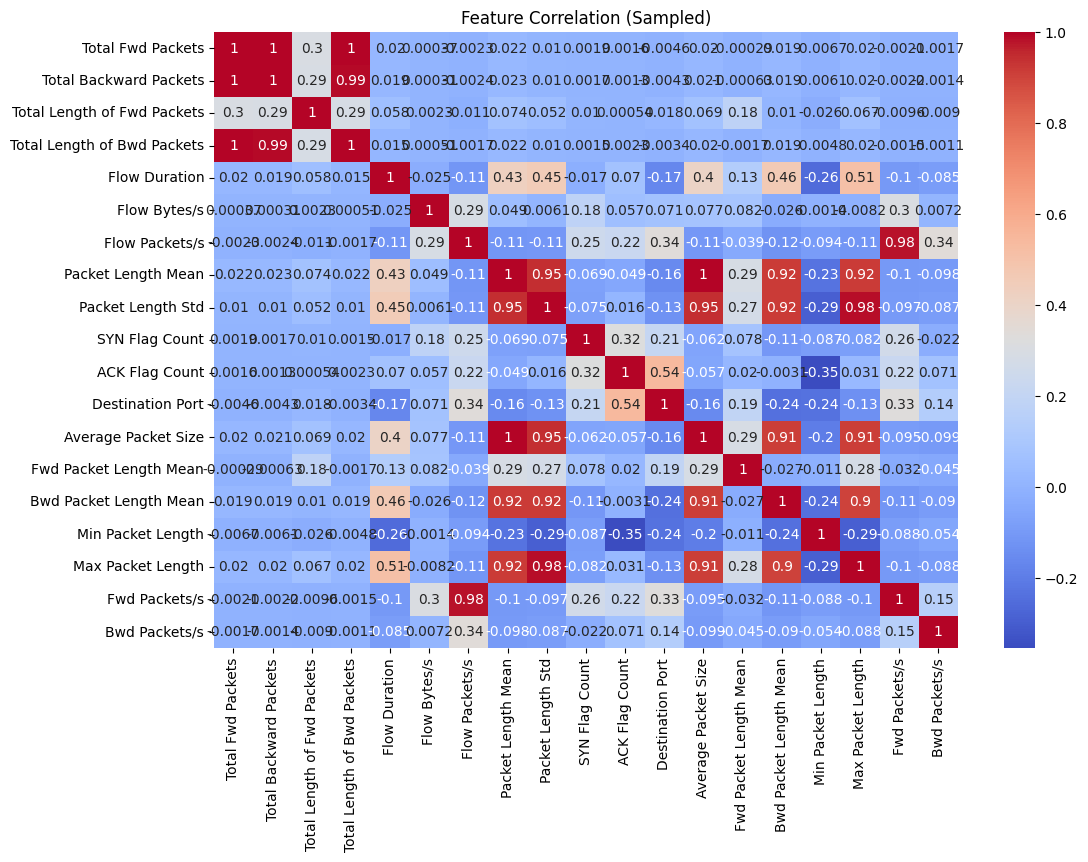

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation (Sampled)")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(  #train test split
    X, y, test_size=0.2, random_state=42, stratify=y
)

# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)  #Applying smote to handle class imbalance
# X_train, y_train = smote.fit_resample(X_train, y_train)

# print("After SMOTE:", y_train.value_counts())

In [8]:
from sklearn.ensemble import RandomForestClassifier

clf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf_model.fit(X_train, y_train)  #train

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

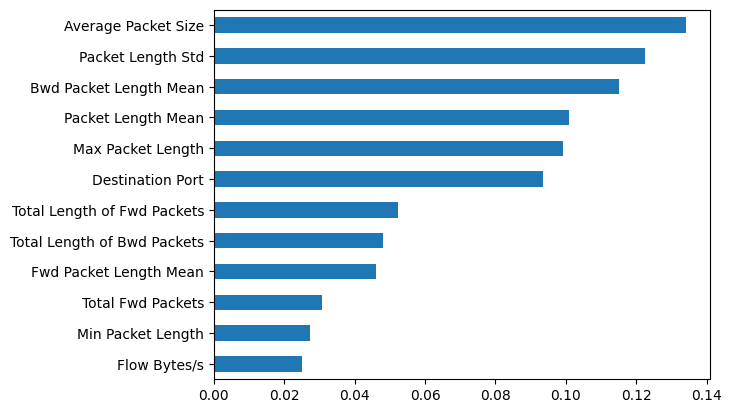

(1615784, 12) (1615784,)
(403946, 12) (403946,)


In [9]:
feature_names = X_train.columns
importance = clf_model.feature_importances_

feat_imp = pd.Series(importance, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

top_features = feat_imp.head(12).index.tolist()

feat_imp.head(12).plot(kind='barh')
plt.gca().invert_yaxis()
plt.show()

X_train_new = X_train[top_features]
X_test_new = X_test[top_features]

print(X_train_new.shape, y_train.shape)
print(X_test_new.shape, y_test.shape)

In [10]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaler.fit(X_train_new)

X_train_scaled=scaler.transform(X_train_new) #numpy array dega
X_test_scaled=scaler.transform(X_test_new)


In [ ]:
# Train again
from sklearn.metrics import confusion_matrix,classification_report 
from sklearn.metrics import recall_score, precision_score

clf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf_model.fit(X_train_scaled, y_train)

y_pred = clf_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print("Recall (Attack detection):", recall_score(y_test, y_pred))
print("Precision (Attack detection):", precision_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    318770
           1       0.93      1.00      0.96     85176

    accuracy                           0.98    403946
   macro avg       0.96      0.99      0.98    403946
weighted avg       0.98      0.98      0.98    403946

Recall (Attack detection): 0.9959730440499671
Precision (Attack detection): 0.9283947644895815


In [13]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),  # adjust if imbalance
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_xgb))
print("Recall (Attack detection):", recall_score(y_test, y_pred_xgb))
print("Precision (Attack detection):", precision_score(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    318770
           1       0.96      0.99      0.97     85176

    accuracy                           0.99    403946
   macro avg       0.98      0.99      0.98    403946
weighted avg       0.99      0.99      0.99    403946

Recall (Attack detection): 0.9868742368742369
Precision (Attack detection): 0.9620592173783663


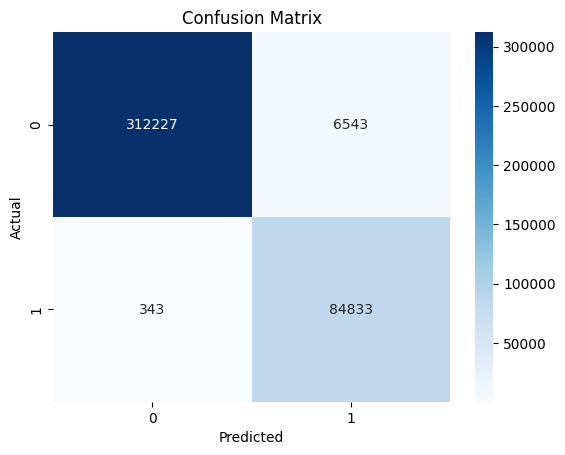

In [14]:
y_pred = clf_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

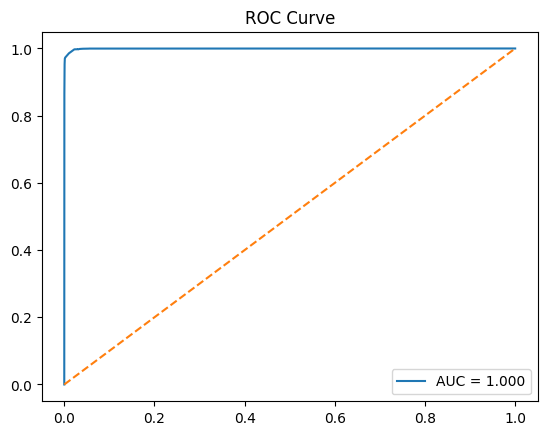

In [15]:
from sklearn.metrics import roc_curve, auc

y_probs = clf_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

#### Anomaly Detection

In [ ]:
from sklearn.ensemble import IsolationForest

X_benign = X_train_scaled[(y_train == 0).values]

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_benign)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [18]:
iso_preds = iso_model.predict(X_test_scaled)
iso_preds = [1 if x == -1 else 0 for x in iso_preds]

print(pd.Series(iso_preds).value_counts())

print("Isolation Forest Performance:")
print(classification_report(y_test, iso_preds))

0    339414
1     64532
Name: count, dtype: int64
Isolation Forest Performance:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92    318770
           1       0.75      0.57      0.65     85176

    accuracy                           0.87    403946
   macro avg       0.82      0.76      0.78    403946
weighted avg       0.86      0.87      0.86    403946



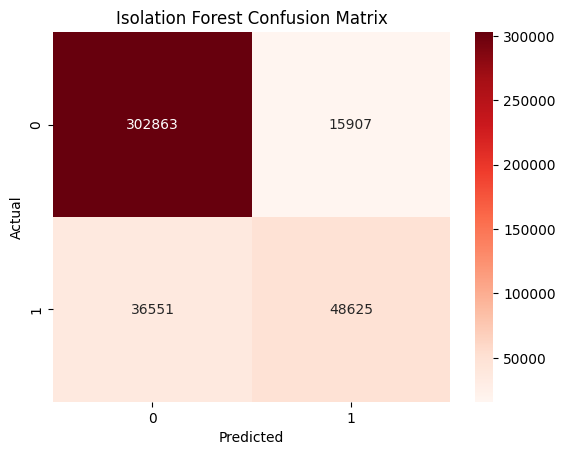

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, iso_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
def hybrid_predict(sample, threshold=0.6):

    sample=sample[top_features]
    sample_scaled=scaler.transform(sample)

    prob = clf_model.predict_proba(sample_scaled)[0][1]
    iso_pred = iso_model.predict(sample_scaled)[0]

    
    # high confidence attack
    if prob > threshold:
        return "🚨 Known Attack"

    # uncertain → anomaly check
    if iso_pred == -1:
        return "⚠️ Unknown Attack"

    return "✅ Normal Traffic"

#### Testing

In [21]:
for i in range(20):
    sample = X_test.iloc[i:i+1]
    
    result = hybrid_predict(sample)
    actual = y_test.iloc[i]

    print(f"Index {i} → Predicted: {result} | Actual: {actual}")

Index 0 → Predicted: 🚨 Known Attack | Actual: 1
Index 1 → Predicted: ✅ Normal Traffic | Actual: 0
Index 2 → Predicted: ✅ Normal Traffic | Actual: 0
Index 3 → Predicted: ✅ Normal Traffic | Actual: 0
Index 4 → Predicted: ✅ Normal Traffic | Actual: 0
Index 5 → Predicted: ✅ Normal Traffic | Actual: 0
Index 6 → Predicted: ✅ Normal Traffic | Actual: 0
Index 7 → Predicted: ✅ Normal Traffic | Actual: 0
Index 8 → Predicted: ✅ Normal Traffic | Actual: 0
Index 9 → Predicted: ✅ Normal Traffic | Actual: 0
Index 10 → Predicted: ✅ Normal Traffic | Actual: 0
Index 11 → Predicted: ✅ Normal Traffic | Actual: 0
Index 12 → Predicted: 🚨 Known Attack | Actual: 1
Index 13 → Predicted: ✅ Normal Traffic | Actual: 0
Index 14 → Predicted: 🚨 Known Attack | Actual: 1
Index 15 → Predicted: ✅ Normal Traffic | Actual: 0
Index 16 → Predicted: ✅ Normal Traffic | Actual: 0
Index 17 → Predicted: 🚨 Known Attack | Actual: 1
Index 18 → Predicted: ✅ Normal Traffic | Actual: 0
Index 19 → Predicted: ✅ Normal Traffic | Actual: 

In [ ]:
attack_sample = X_test[y_test == 1].iloc[0]
normal_sample = X_test[y_test == 0].iloc[0]

import joblib

joblib.dump(clf_model, "../models/rf_model.pkl")
joblib.dump(iso_model, "../models/iso_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")  
joblib.dump(top_features, "../models/features.pkl")
joblib.dump(attack_sample, "../models/sample_attack.pkl")
joblib.dump(normal_sample, "../models/sample_normal.pkl")

['../models/features.pkl']